In [4]:
# Mount google drive to current runtime session to access required files
'''
from google.colab import drive
drive.mount('/content/drive')
'''

"\nfrom google.colab import drive\ndrive.mount('/content/drive')\n"

In [5]:
# Import spectrogram zip to local storage for efficient loading
'''
import os
import shutil

shutil.copy('/content/drive/MyDrive/6600_project/piano_roll_150014.zip', '/content/piano_roll_150014.zip')

!unzip -q piano_roll_150014.zip -d /content/

!du -sh /content/piano_roll/*
!find /content/piano_roll -type f | wc -l

'''

"\nimport os\nimport shutil\n\nshutil.copy('/content/drive/MyDrive/6600_project/piano_roll_150014.zip', '/content/piano_roll_150014.zip')\n\n!unzip -q piano_roll_150014.zip -d /content/\n\n!du -sh /content/piano_roll/*\n!find /content/piano_roll -type f | wc -l\n\n"

In [6]:
# Import Libraries
import os
import shutil
import time
import random
import itertools
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset

In [7]:
df = pd.read_csv('/content/drive/MyDrive/6600_project/lmd_full_metadata.csv', parse_dates=False)

# Filter out missing BPM
df = df[
    df['initial_bpm'].notna() & (df['initial_bpm'] != '') &
    df["duration_s"].between(15,600) &
    df["initial_bpm"].between(30,240) &
    df["n_notes"].between(50, 50_000)
    ]

print(f"Total usable samples: {len(df)}")
print(f"Distribution of BPM:\n{df['initial_bpm'].describe()}")
df.head(3)

Total usable samples: 150017
Distribution of BPM:
count    150017.000000
mean        114.163743
std          33.206190
min          30.000000
25%          91.000000
50%         115.000000
75%         130.000000
max         240.000000
Name: initial_bpm, dtype: float64


,file,filepath,duration_s,resolution,n_instruments,n_notes,n_tempo_changes,initial_bpm,n_key_changes,initial_key,n_time_sig_changes,initial_time_sig,key_name
0,d66652ff61cdea1eda265490600e6e40.mid,../data/raw_data/lmd_full/d/d66652ff61cdea1eda...,176.59,384,11,5244,1,118.0,0,NaN,1,4/4,NaN
1,d1e757857fb459edf3e543c3c8a79c6a.mid,../data/raw_data/lmd_full/d/d1e757857fb459edf3...,219.15,192,10,4974,1,72.0,0,NaN,1,4/4,NaN
2,d597590e6423c93180f56f2854bfb109.mid,../data/raw_data/lmd_full/d/d597590e6423c93180...,176.97,384,5,3965,62,120.0,13,0.0,2,1/4,C major


# Checking for corrupted files

In [8]:
df['npy_file'] = df['file'].str.replace(r'\.mid$', '.npy', regex=True)

# Build full file paths
data_dir = '/content/piano_roll/'
df['file_path'] = data_dir + df['npy_file']

# Check which files actually exist
df['file_exists'] = df['file_path'].apply(os.path.exists)

print(f"Files found:   {df['file_exists'].sum()} in csv filepath")
print(f"Number of missing file is {(~df['file_exists']).sum()} from the list")

# Keep only existing files
df = df[df['file_exists']]

tqdm.pandas()  # enables progress_apply

df = df[df['file_path'].progress_apply(
    lambda p: np.load(p).shape == (128, 468)
)]

print("")
print(f"Remaining samples after removing different shapes: {len(df)}")

Files found:   150014 in csv filepath
Number of missing file is 3 from the list


100%|██████████| 150014/150014 [00:15<00:00, 9666.25it/s]


Remaining samples after removing different shapes: 150014


In [9]:
piano_roll_dir = '/content/piano_roll'
files = [f for f in os.listdir(piano_roll_dir) if f.endswith('.npy')]

random_samples = random.sample(files, 3)

for file in random_samples:
    file_path = os.path.join(piano_roll_dir, file)
    sample = np.load(file_path)
    print(f"File: {file}")
    print(f"  Shape: {sample.shape}")
    print(f"  Dtype: {sample.dtype}")
    print(f"  Min: {sample.min():.4f}, Max: {sample.max():.4f}\n")

File: f09459b25cd4d00bcf73accdc3195d4e.npy
  Shape: (128, 468)
  Dtype: uint8
  Min: 0.0000, Max: 193.0000

File: a43738f0123020ccb9ad51ff8e296447.npy
  Shape: (128, 468)
  Dtype: uint8
  Min: 0.0000, Max: 100.0000

File: 7e2024dfbbac69b3ded57ac6c708c606.npy
  Shape: (128, 468)
  Dtype: uint8
  Min: 0.0000, Max: 202.0000



# Start of CNN&GRU Models


In [10]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU')

2.10.0+cu128
True
NVIDIA A100-SXM4-40GB


In [11]:
Path("/content/piano_roll")

METADATA_CSV      = Path("/content/drive/MyDrive/lmd_full_metadata.csv")
DATA_DIR          = Path("/content/piano_roll")
SAVE              = Path("/content/models")
MODEL01_SAVE_PATH = Path("/content/models/cnn_bpm_regressor.pt")
MODEL02_SAVE_PATH = Path("/content/models/gru_bpm_regressor.pt")

# Ensure required directories exist
SAVE.mkdir(parents=True, exist_ok=True)


# ── Data filters ──────────────────────────────────────────────────────────────
TARGET      = 'initial_bpm'
BPM_MIN     = 30
BPM_MAX     = 240
MAX_SAMPLES = None   # set int (e.g. 10_000) for quick dev runs; None = all

# ── Model / training hyperparameters ─────────────────────────────────────────
FS           = 31.25
SEGMENT_LEN  = 468   # actual piano-roll length: 15 s × 31.25 fps = 468 frames
N_PITCH      = 128
BATCH_SIZE   = 1024
LR           = 1e-3
WEIGHT_DECAY = 1e-4
N_EPOCHS     = 15
PATIENCE     = 3
DROPOUT      = 0.5   # shared dropout rate used by all models
SEED         = 66

# ── Default hyperparameters ─────────────────────────────────────────────────
DEFAULT_LR      = 3e-4
DEFAULT_DROPOUT = 0.3
DEFAULT_CNN     = 4
DEFAULT_MLP     = 1

# ── Hyperparameter search grids ───────────────────────────────────────────────
LR_SEARCH      = [1e-3, 5e-4, 3e-4, 1e-4, 1e-5]
DROPOUT_SEARCH = [0.2, 0.3, 0.4]
CNN_ARCH_CONFIGS = [
    {'num_cnn_layers': 3, 'num_mlp_layers': 1},
    {'num_cnn_layers': 4, 'num_mlp_layers': 1},
    {'num_cnn_layers': 5, 'num_mlp_layers': 1},
    {'num_cnn_layers': 5, 'num_mlp_layers': 2},
]

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Device: cuda


In [12]:
class PianoRollDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        x = np.load(self.file_paths[idx]).astype(np.float32)
        x = x / 127.0                        # normalize velocity 0-127 → 0-1
        x = x[np.newaxis, :, :]              # add channel dim → (1, 128, 468)
        return torch.tensor(x), torch.tensor(self.labels[idx], dtype=torch.float32)

In [13]:
file_paths = df['file_path'].tolist()
bpms = df['initial_bpm'].tolist()

# Split into train(0.8), val(0.1), test(0.1)
X_train, X_temp, y_train_raw, y_temp_raw = train_test_split(
    file_paths, bpms,
    test_size=0.2,
    random_state=SEED
)

X_val, X_test, y_val_raw, y_test_raw = train_test_split(
    X_temp, y_temp_raw,
    test_size=0.5,
    random_state=SEED
)

# Calculate mean and std ONLY from the training set to prevent data leakage
bpm_mean = np.mean(y_train_raw)
bpm_std  = np.std(y_train_raw)

print(f"Training BPM Mean: {bpm_mean:.2f}, Std: {bpm_std:.2f}")

# Normalize the targets using training set statistics
y_train = [(y - bpm_mean) / bpm_std for y in y_train_raw]
y_val   = [(y - bpm_mean) / bpm_std for y in y_val_raw]
y_test  = [(y - bpm_mean) / bpm_std for y in y_test_raw]

print(f"Train samples: {len(X_train)}")
print(f"Val samples:   {len(X_val)}")
print(f"Test samples:  {len(X_test)}")

train_dataset = PianoRollDataset(X_train, y_train)
val_dataset   = PianoRollDataset(X_val,   y_val)
test_dataset  = PianoRollDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=8, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=8, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=8, pin_memory=True)

Training BPM Mean: 114.16, Std: 33.24
Train samples: 120011
Val samples:   15001
Test samples:  15002


# Training Method

In [14]:
def train_model(model, train_loader, val_loader, bpm_std, epochs=N_EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY, checkpoint_path='checkpoint.pth', device=DEVICE):
    start = time.time()

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scaler = GradScaler('cuda') if device == 'cuda' else None
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.7)

    model_class_name = model.__class__.__name__
    print(f"The model class name is: {model_class_name}")

    best_val_mae = float('inf')
    epochs_no_improve = 0

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        running_loss = 0.0
        running_mae  = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            if device == 'cuda':
                with autocast('cuda'):
                    outputs = model(images).squeeze()
                    loss = criterion(outputs, labels)

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(images).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            running_loss += loss.item()
            running_mae  += torch.abs(outputs - labels).mean().item()

        train_mae     = running_mae / len(train_loader)
        train_mae_bpm = train_mae * bpm_std

        # --- Validation ---
        model.eval()
        val_mae = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images).squeeze()
                val_mae += torch.abs(outputs - labels).mean().item()

        val_mae     = val_mae / len(val_loader)
        val_mae_bpm = val_mae * bpm_std

        # --- Checkpoint (save best only) ---
        dir_name = os.path.dirname(str(checkpoint_path))
        if dir_name:
            os.makedirs(dir_name, exist_ok=True)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            epochs_no_improve = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
            }, checkpoint_path)
            saved_marker = " ✓ saved"
        else:
            epochs_no_improve += 1
            saved_marker = f" (no improvement {epochs_no_improve}/{PATIENCE})"

        print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Train MAE: {train_mae_bpm:.1f} BPM | Val MAE: {val_mae_bpm:.1f} BPM{saved_marker}")
        scheduler.step()
        print(f"LR: {scheduler.get_last_lr()[0]:.6f}")

        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping triggered after {epoch+1} epochs (no val improvement for {PATIENCE} epochs).")
            break

    end = time.time()
    print(f"Total training time: {(end-start)/60:.1f} minutes")

    return best_val_mae * bpm_std  # best val MAE in BPM

# Testing method

In [15]:
def test_model_and_plot(model, test_loader, bpm_std, bpm_mean, checkpoint_path=None, device=DEVICE):
    if checkpoint_path and os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded weights from {checkpoint_path} (Epoch {checkpoint.get('epoch', 'unknown')})")
    else:
        print("No checkpoint loaded. Using current model weights.")

    model.eval()
    val_mae = 0.0
    predictions = []
    actuals = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze()

            # Convert back to original BPM scale
            pred_bpm = (outputs * bpm_std) + bpm_mean
            actual_bpm = (labels * bpm_std) + bpm_mean

            if outputs.dim() == 0:
                pred_bpm = pred_bpm.unsqueeze(0)
                actual_bpm = actual_bpm.unsqueeze(0)

            predictions.extend(pred_bpm.cpu().numpy())
            actuals.extend(actual_bpm.cpu().numpy())

            val_mae += torch.abs(outputs - labels).mean().item()

    val_mae = val_mae / len(test_loader)
    val_mae_bpm = val_mae * bpm_std

    print(f"\nTest MAE: {val_mae_bpm:.2f} BPM")

    # Plotting Actual vs Predicted (Dot Plot)
    plt.figure(figsize=(8, 6))
    plt.scatter(actuals, predictions, alpha=0.3, color='blue', s=10)

    # Perfect prediction diagonal line
    min_val = min(min(actuals), min(predictions))
    max_val = max(max(actuals), max(predictions))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

    plt.xlabel('Actual BPM')
    plt.ylabel('Predicted BPM')
    plt.title('Dot Plot: Actual vs Predicted BPM')
    plt.legend()
    plt.grid(True)
    plt.show()

    return np.array(predictions), np.array(actuals)

# CNN Structure (Dynamic)

In [16]:
class SpectrogramCNNDynamic(nn.Module):
    def __init__(self, num_cnn_layers=5, num_mlp_layers=1, dropout=DROPOUT):
        super().__init__()

        # Dynamic CNN feature extractor: channels 1→32→64→128→256→512
        cnn_channels = [1, 32, 64, 128, 256, 512]
        layers = []
        for i in range(num_cnn_layers):
            layers += [
                nn.Conv2d(cnn_channels[i], cnn_channels[i+1], kernel_size=3, padding=1),
                nn.BatchNorm2d(cnn_channels[i+1]),
                nn.ReLU(),
                nn.MaxPool2d(2, 2)
            ]
        self.features = nn.Sequential(*layers)

        # Flat size after n pools on (128, 468)
        out_c = cnn_channels[num_cnn_layers]
        out_h = 128 // (2 ** num_cnn_layers)
        out_w = 468 // (2 ** num_cnn_layers)
        flat_size = out_c * out_h * out_w

        if num_mlp_layers == 1:
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(flat_size, 512),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(512, 256),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(256, 1),
            )
        else:  # 2-layer MLP
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(flat_size, 512),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(512, 256),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(128, 1),
            )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


# CNN Hyperparameter Search

In [17]:
# ── CNN Sequential Hyperparameter Search ────────────────────────────────────
# Strategy: for each architecture, sweep LR (5 runs), then dropout (3 runs)
# — all others fixed at defaults.  8 runs × 4 archs = 32 total.
cnn_results = []
runs_per_arch = len(LR_SEARCH) + len(DROPOUT_SEARCH)  # 5+3=8
total_runs    = len(CNN_ARCH_CONFIGS) * runs_per_arch
run_idx       = 0

for arch_i, arch in enumerate(CNN_ARCH_CONFIGS, 1):
    num_cnn = arch['num_cnn_layers']
    num_mlp = arch['num_mlp_layers']
    arch_tag = f"cnn{num_cnn}_mlp{num_mlp}"

    # ── Phase 1: LR sweep (dropout=DEFAULT) ──────────────────────────────
    for lr in LR_SEARCH:
        run_idx += 1
        dropout = DEFAULT_DROPOUT
        print(f"\n{'='*70}")
        print(f"[CNN {run_idx}/{total_runs}]  Arch {arch_i}/{len(CNN_ARCH_CONFIGS)} ({arch_tag})  |  LR sweep")
        print(f"  lr={lr:.0e}  dropout={dropout}  cnn={num_cnn}  mlp={num_mlp}")
        print(f"{'='*70}")

        ckpt = Path(f"/content/models/cnn_{arch_tag}_lr{lr:.0e}_do{dropout}.pt")
        model = SpectrogramCNNDynamic(
            num_cnn_layers=num_cnn,
            num_mlp_layers=num_mlp,
            dropout=dropout
        ).to(DEVICE)
        best_mae_bpm = train_model(
            model, train_loader, val_loader, bpm_std,
            epochs=N_EPOCHS, lr=lr, weight_decay=WEIGHT_DECAY,
            checkpoint_path=ckpt, device=DEVICE
        )
        cnn_results.append({
            'lr': lr, 'dropout': dropout,
            'num_cnn_layers': num_cnn, 'num_mlp_layers': num_mlp,
            'val_mae_bpm': best_mae_bpm, 'ckpt': ckpt
        })
        print(f"  → best val MAE = {best_mae_bpm:.2f} BPM")

    # ── Phase 2: Dropout sweep (lr=DEFAULT) ──────────────────────────────
    for dropout in DROPOUT_SEARCH:
        run_idx += 1
        lr = DEFAULT_LR
        print(f"\n{'='*70}")
        print(f"[CNN {run_idx}/{total_runs}]  Arch {arch_i}/{len(CNN_ARCH_CONFIGS)} ({arch_tag})  |  Dropout sweep")
        print(f"  lr={lr:.0e}  dropout={dropout}  cnn={num_cnn}  mlp={num_mlp}")
        print(f"{'='*70}")

        ckpt = Path(f"/content/models/cnn_{arch_tag}_lr{lr:.0e}_do{dropout}.pt")
        model = SpectrogramCNNDynamic(
            num_cnn_layers=num_cnn,
            num_mlp_layers=num_mlp,
            dropout=dropout
        ).to(DEVICE)
        best_mae_bpm = train_model(
            model, train_loader, val_loader, bpm_std,
            epochs=N_EPOCHS, lr=lr, weight_decay=WEIGHT_DECAY,
            checkpoint_path=ckpt, device=DEVICE
        )
        cnn_results.append({
            'lr': lr, 'dropout': dropout,
            'num_cnn_layers': num_cnn, 'num_mlp_layers': num_mlp,
            'val_mae_bpm': best_mae_bpm, 'ckpt': ckpt
        })
        print(f"  → best val MAE = {best_mae_bpm:.2f} BPM")

# ── Summary ───────────────────────────────────────────────────────────────────
cnn_results_df = pd.DataFrame(cnn_results).sort_values('val_mae_bpm').reset_index(drop=True)
print("\n=== CNN Hyperparameter Search Results (sorted by val MAE) ===")
print(cnn_results_df[['lr', 'dropout', 'num_cnn_layers', 'num_mlp_layers', 'val_mae_bpm']].to_string(index=False))

best_cnn = cnn_results_df.iloc[0]
shutil.copy(best_cnn['ckpt'], MODEL01_SAVE_PATH)
print(f"\nBest CNN → lr={best_cnn['lr']:.0e}, dropout={best_cnn['dropout']}, "
      f"cnn={int(best_cnn['num_cnn_layers'])}, mlp={int(best_cnn['num_mlp_layers'])}, "
      f"val MAE={best_cnn['val_mae_bpm']:.2f} BPM")
print(f"Best checkpoint saved to {MODEL01_SAVE_PATH}")

# ── Save all results to CSV ──────────────────────────────────────────────────
csv_local  = SAVE / 'cnn_search_results.csv'
csv_drive  = Path('/content/drive/MyDrive/6600_project/cnn_search_results.csv')
cnn_results_df.to_csv(csv_local, index=False)
shutil.copy(csv_local, csv_drive)
print(f"Results saved to {csv_drive}")




[CNN 1/32]  Arch 1/4 (cnn3_mlp1)  |  LR sweep
  lr=1e-03  dropout=0.3  cnn=3  mlp=1
The model class name is: SpectrogramCNNDynamic
Epoch  1/15 | Loss: 83.7116 | Train MAE: 118.5 BPM | Val MAE: 25.0 BPM ✓ saved
LR: 0.001000
Epoch  2/15 | Loss: 0.9735 | Train MAE: 24.9 BPM | Val MAE: 23.3 BPM ✓ saved
LR: 0.001000
Epoch  3/15 | Loss: 0.8679 | Train MAE: 23.5 BPM | Val MAE: 22.7 BPM ✓ saved
LR: 0.001000
Epoch  4/15 | Loss: 0.8434 | Train MAE: 23.1 BPM | Val MAE: 22.1 BPM ✓ saved
LR: 0.001000
Epoch  5/15 | Loss: 0.8303 | Train MAE: 22.8 BPM | Val MAE: 22.1 BPM ✓ saved
LR: 0.001000
Epoch  6/15 | Loss: 0.8198 | Train MAE: 22.6 BPM | Val MAE: 22.2 BPM (no improvement 1/3)
LR: 0.001000
Epoch  7/15 | Loss: 0.8140 | Train MAE: 22.5 BPM | Val MAE: 21.8 BPM ✓ saved
LR: 0.000700
Epoch  8/15 | Loss: 0.7985 | Train MAE: 22.2 BPM | Val MAE: 21.9 BPM (no improvement 1/3)
LR: 0.000700
Epoch  9/15 | Loss: 0.7951 | Train MAE: 22.1 BPM | Val MAE: 21.7 BPM ✓ saved
LR: 0.000700
Epoch 10/15 | Loss: 0.7894 | T


--- Testing Best CNN ---
Loaded weights from /content/models/cnn_bpm_regressor.pt (Epoch 13)


Evaluating: 100%|██████████| 15/15 [00:11<00:00,  1.31it/s]



Test MAE: 18.03 BPM


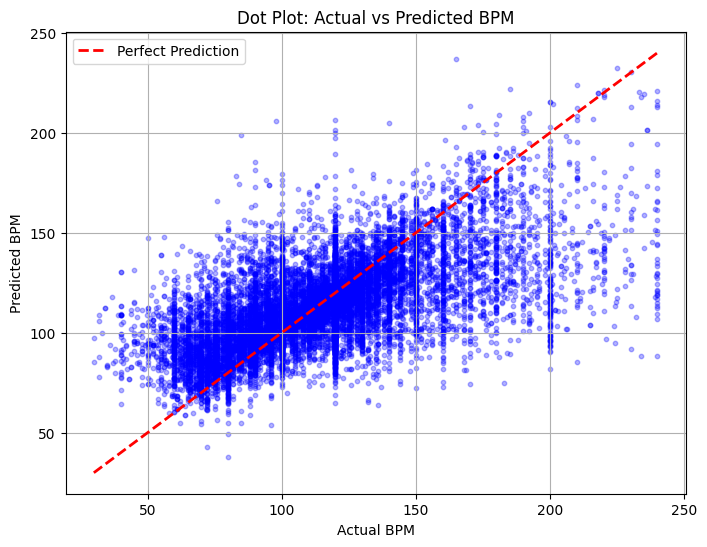

In [18]:
# Test Best CNN Model
print("\n--- Testing Best CNN ---")
cnn_model = SpectrogramCNNDynamic(
    num_cnn_layers=int(best_cnn['num_cnn_layers']),
    num_mlp_layers=int(best_cnn['num_mlp_layers']),
    dropout=best_cnn['dropout']
).to(DEVICE)
cnn_preds, cnn_actuals = test_model_and_plot(
    cnn_model, test_loader, bpm_std, bpm_mean,
    checkpoint_path=MODEL01_SAVE_PATH, device=DEVICE
)
